# Why JEPA needs a target encoder (toy demo)

This notebook is **not** about the ABM. It is a minimal picture of the training
dynamics behind the two-encoder EMA setup in `jepa_control`.

We train a tiny encoder + linear predictor on a synthetic trajectory and compare:

| Mode | Context `x_t` | Target `x_{t+1}` | What to watch |
|---|---|---|---|
| `online_both` | online encoder | **same** online encoder, **gradients through both** | loss → 0 while the latent collapses |
| `stopgrad` | online | same encoder, **detached** target | blocks the double-gradient cheat |
| `ema` | online | **slow EMA copy** (no grad) | same as stop-grad, but the target moves slowly |
| `ema + VICReg` | online | EMA | repo default: predictable *and* non-collapsed |

Slide takeaway:

> Predicting your own future embedding only works if (1) the target is a
> **stable** definition of "future" and (2) something **prevents collapse**.
> Stop-grad / EMA do (1). VICReg does (2).

In [1]:
from __future__ import annotations

import copy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")
print("torch", torch.__version__, "| device", device)

torch 2.12.1 | device cpu


## 1. Toy world: a rotating phase in 2D observations

True state is a scalar angle $\phi_t$ that advances by a fixed step each time.
Observations are the unit-circle embedding plus a little noise:

$$
x_t = \big(\cos\phi_t,\;\sin\phi_t\big) + \varepsilon_t
$$

A good latent should recover something like $\phi$ (or its 2D embedding).
A collapsed latent is a near-constant point — prediction loss can still be tiny.

pairs: 4000  |  obs dim: 2


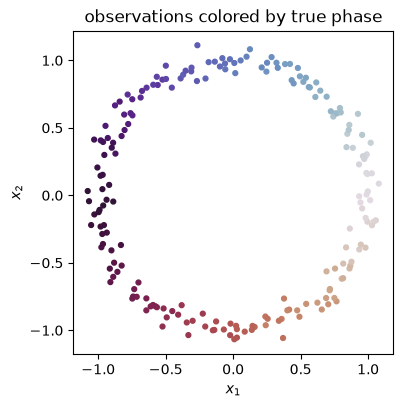

In [2]:
def make_trajectory(n: int = 4000, dphi: float = 0.35, noise: float = 0.05):
    """Return (x_t, x_{t+1}, phi_t, phi_{t+1}) as float32 arrays."""
    phi = np.cumsum(np.full(n + 1, dphi, dtype=np.float64))
    phi = (phi + np.random.randn(n + 1) * 0.02) % (2 * np.pi)
    xy = np.stack([np.cos(phi), np.sin(phi)], axis=1).astype(np.float32)
    xy = xy + noise * np.random.randn(*xy.shape).astype(np.float32)
    return xy[:-1], xy[1:], phi[:-1].astype(np.float32), phi[1:].astype(np.float32)


x_t, x_tp1, phi_t, phi_tp1 = make_trajectory()
print(f"pairs: {len(x_t)}  |  obs dim: {x_t.shape[1]}")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(x_t[::20, 0], x_t[::20, 1], c=phi_t[::20], s=12, cmap="twilight")
ax.set_aspect("equal")
ax.set_title("observations colored by true phase")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

## 2. Tiny JEPA pieces

- **Encoder** $f_\theta$: small MLP $2 \to 16 \to 2$ (latent dim 2, so we can plot it).
- **Predictor** $g_\psi$: linear map $z_t \mapsto \hat z_{t+1}$ (no control — keep the story about targets).
- **EMA teacher** $\bar\theta \leftarrow \tau\bar\theta + (1-\tau)\theta$ after each step.

Optional **VICReg** variance hinge keeps per-dim std from collapsing to 0.

In [3]:
class TinyEncoder(nn.Module):
    def __init__(self, latent_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, latent_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def vicreg_var(z: torch.Tensor) -> torch.Tensor:
    """Hinge: push each latent dim's std toward >= 1."""
    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return torch.mean(F.relu(1.0 - std))


@dataclass
class TrainLog:
    pred_loss: list[float]
    latent_std: list[float]
    phase_r2: list[float]
    target_drift: list[float]  # ||z_tgt - z_online_on_same_x||


def phase_r2(z: np.ndarray, phi: np.ndarray) -> float:
    """How well a linear readout of z recovers [cos φ, sin φ].

    Returns 0 under collapse: a near-constant z makes least-squares R²
    numerically meaningless (and can spuriously look high).
    """
    if float(z.std(axis=0).mean()) < 1e-3:
        return 0.0
    y = np.stack([np.cos(phi), np.sin(phi)], axis=1)
    zc = z - z.mean(0, keepdims=True)
    yc = y - y.mean(0, keepdims=True)
    beta, *_ = np.linalg.lstsq(zc, yc, rcond=None)
    pred = zc @ beta
    ss_res = ((yc - pred) ** 2).sum()
    ss_tot = (yc**2).sum()
    return float(1.0 - ss_res / max(ss_tot, 1e-12))


def train_mode(
    mode: str,
    *,
    steps: int = 2500,
    batch_size: int = 128,
    lr: float = 3e-3,
    ema_decay: float = 0.99,
    w_vic: float = 0.0,
    seed: int = 0,
) -> tuple[TinyEncoder, nn.Module, TrainLog, dict]:
    """Train one target mode.

    modes
    -----
    online_both : encode x_t and x_{t+1} with the online encoder; grads on BOTH.
    stopgrad    : target = online(x_{t+1}).detach()
    ema         : target = ema_encoder(x_{t+1}) (no grad); EMA update after step
    """
    if mode not in {"online_both", "stopgrad", "ema"}:
        raise ValueError(mode)

    g = torch.Generator().manual_seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)

    enc = TinyEncoder().to(device)
    pred = nn.Linear(2, 2, bias=True).to(device)
    with torch.no_grad():
        pred.weight.copy_(torch.eye(2))
        pred.bias.zero_()

    target_enc: TinyEncoder | None = None
    if mode == "ema":
        target_enc = copy.deepcopy(enc)
        target_enc.requires_grad_(False)
        target_enc.eval()

    opt = torch.optim.Adam(
        list(enc.parameters()) + list(pred.parameters()), lr=lr
    )

    xt = torch.tensor(x_t, device=device)
    xtp1 = torch.tensor(x_tp1, device=device)
    n = xt.shape[0]

    log = TrainLog([], [], [], [])
    snapshots: dict[int, dict] = {}
    snapshot_at = {0, steps // 4, steps // 2, steps}

    def evaluate() -> tuple[float, float, float]:
        enc.eval()
        with torch.no_grad():
            z = enc(xt).cpu().numpy()
            z_online_on_tp1 = enc(xtp1)
            if mode == "ema":
                assert target_enc is not None
                z_tgt = target_enc(xtp1)
            else:
                z_tgt = z_online_on_tp1
            drift = (z_tgt - z_online_on_tp1).pow(2).mean().item()
            std = float(z.std(axis=0).mean())
            r2 = phase_r2(z, phi_t)
        enc.train()
        return std, r2, drift

    std0, r20, d0 = evaluate()
    log.latent_std.append(std0)
    log.phase_r2.append(r20)
    log.target_drift.append(d0)
    log.pred_loss.append(float("nan"))
    snapshots[0] = {
        "z": enc(xt).detach().cpu().numpy(),
        "std": std0,
        "r2": r20,
    }

    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), generator=g, device=device)
        xb, yb = xt[idx], xtp1[idx]

        z_ctx = enc(xb)
        z_hat = pred(z_ctx)

        if mode == "online_both":
            # THE FAILURE MODE: same encoder on the future, gradients through both.
            z_tgt = enc(yb)
        elif mode == "stopgrad":
            z_tgt = enc(yb).detach()
        else:  # ema
            assert target_enc is not None
            with torch.no_grad():
                z_tgt = target_enc(yb)

        loss_pred = F.mse_loss(z_hat, z_tgt)
        loss = loss_pred
        if w_vic > 0:
            # VICReg on online encodings of both times (as in the real model).
            loss = loss + w_vic * vicreg_var(torch.cat([z_ctx, enc(yb)], dim=0))

        opt.zero_grad()
        loss.backward()
        opt.step()

        if mode == "ema":
            assert target_enc is not None
            with torch.no_grad():
                for p_s, p_t in zip(enc.parameters(), target_enc.parameters(), strict=True):
                    p_t.data.mul_(ema_decay).add_(p_s.data, alpha=1.0 - ema_decay)

        if step % 25 == 0 or step in snapshot_at:
            std, r2, drift = evaluate()
            log.pred_loss.append(loss_pred.item())
            log.latent_std.append(std)
            log.phase_r2.append(r2)
            log.target_drift.append(drift)

        if step in snapshot_at:
            with torch.no_grad():
                snapshots[step] = {
                    "z": enc(xt).cpu().numpy(),
                    "std": log.latent_std[-1],
                    "r2": log.phase_r2[-1],
                }

    return enc, pred, log, snapshots

## 3. Train the four stories side by side

Same data, same architecture, same seed — only the **target rule** (and one VICReg flag) changes.

In [4]:
configs = [
    ("online_both", dict(mode="online_both", w_vic=0.0)),
    ("stopgrad", dict(mode="stopgrad", w_vic=0.0)),
    ("ema", dict(mode="ema", w_vic=0.0)),
    ("ema + VICReg", dict(mode="ema", w_vic=1.0)),
]

results = {}
for name, kwargs in configs:
    print(f"training {name} ...", flush=True)
    enc, pred, log, snaps = train_mode(**kwargs, steps=2500, seed=0)
    results[name] = {"enc": enc, "pred": pred, "log": log, "snaps": snaps}
    print(
        f"  final latent std={log.latent_std[-1]:.3f}  "
        f"phase R²={log.phase_r2[-1]:.3f}"
    )

training online_both ...
  final latent std=0.000  phase R²=0.000
training stopgrad ...
  final latent std=2.598  phase R²=0.997
training ema ...
  final latent std=0.324  phase R²=0.920
training ema + VICReg ...
  final latent std=2.741  phase R²=0.997


## 4. Curves: loss can lie — watch the latent

- **pred loss ↓** is necessary but not sufficient.
- **latent std → 0** means collapse: everything maps to one point, prediction is trivial.
- **phase R²** asks: does $z$ still contain the true state?

Expect `online_both` to drive loss to ~0 **and** kill the latent. The other modes keep phase information.

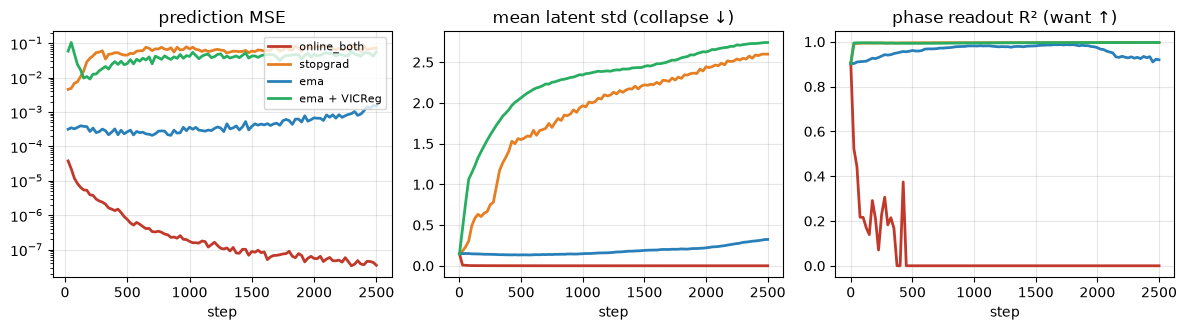

In [5]:
colors = {
    "online_both": "#c0392b",
    "stopgrad": "#e67e22",
    "ema": "#2980b9",
    "ema + VICReg": "#27ae60",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
metrics = [
    ("pred_loss", "prediction MSE", True),
    ("latent_std", "mean latent std (collapse ↓)", False),
    ("phase_r2", "phase readout R² (want ↑)", False),
]

for ax, (attr, title, logy) in zip(axes, metrics):
    for name, pack in results.items():
        y = getattr(pack["log"], attr)
        x = np.linspace(0, 2500, len(y))
        ax.plot(x, y, label=name, color=colors[name], lw=2)
    ax.set_title(title)
    ax.set_xlabel("step")
    if logy:
        ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

## 5. Latent snapshots: what did each mode actually learn?

Each panel is the online encoder's 2D latent, colored by true phase.
A healthy run looks like a circle / arc. Collapse looks like a speck.

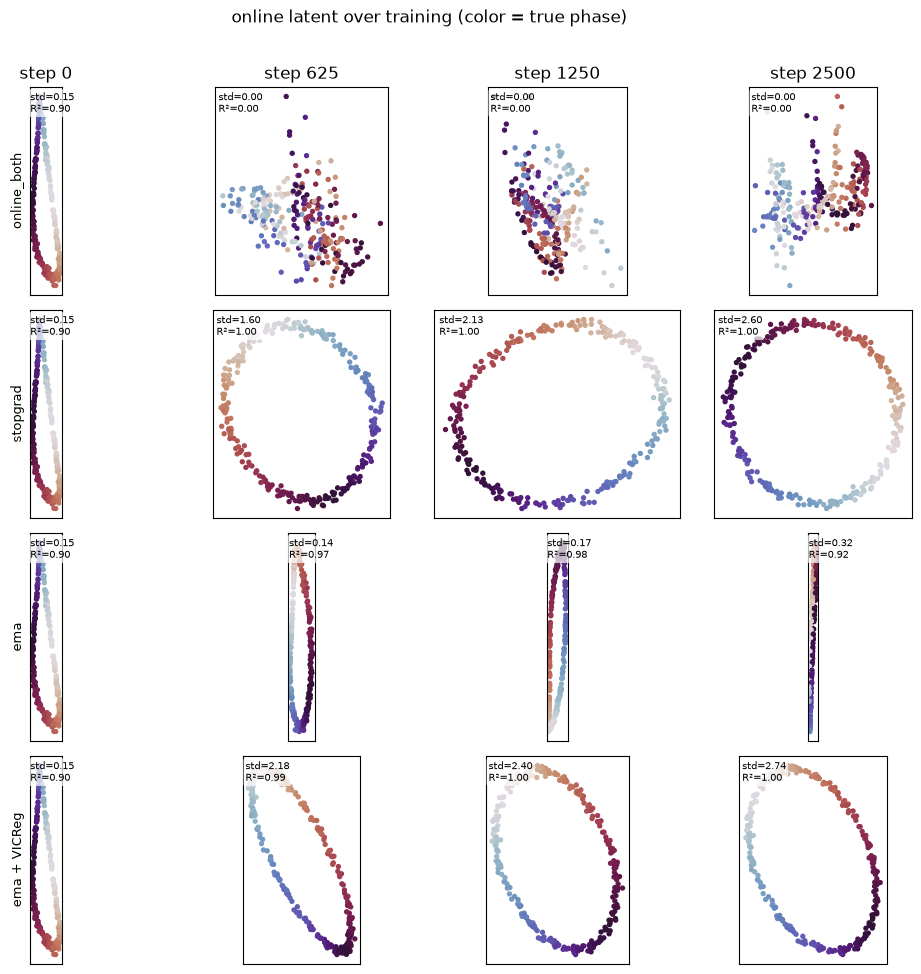

In [6]:
steps_show = [0, 625, 1250, 2500]
names = list(results.keys())

fig, axes = plt.subplots(
    len(names), len(steps_show), figsize=(10.5, 2.4 * len(names)), squeeze=False
)

for i, name in enumerate(names):
    for j, step in enumerate(steps_show):
        ax = axes[i][j]
        snap = results[name]["snaps"][step]
        z = snap["z"]
        ax.scatter(z[::15, 0], z[::15, 1], c=phi_t[::15], s=8, cmap="twilight")
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"step {step}")
        if j == 0:
            ax.set_ylabel(name, fontsize=9)
        ax.text(
            0.02,
            0.98,
            f"std={snap['std']:.2f}\nR²={snap['r2']:.2f}",
            transform=ax.transAxes,
            va="top",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0),
        )

fig.suptitle("online latent over training (color = true phase)", y=1.01)
fig.tight_layout()
plt.show()

## 6. Why `online_both` is a cheat

With gradients through **both** $f_\theta(x_t)$ and $f_\theta(x_{t+1})$, the encoder can
shrink *all* embeddings toward the same point. Then

$$
\|g(f(x_t)) - f(x_{t+1})\| \to 0
$$

even if $g$ is nearly the identity — because both sides became the same constant.
In the curves above that is exactly what `online_both` does: **prediction MSE → 0
while latent std → 0**.

Stop-grad / EMA remove the ability to "move the target to meet the prediction" in the
same backward pass. On this easy circle toy that is often enough to keep a useful
latent. In harder settings (and in the real ABM model) a constant encoder is still a
fixed point of the predictive loss alone, so **VICReg** forbids that solution.

EMA's extra job on top of stop-grad: the target lives in a **slowly moving**
coordinate system. The next cell measures that jump directly.

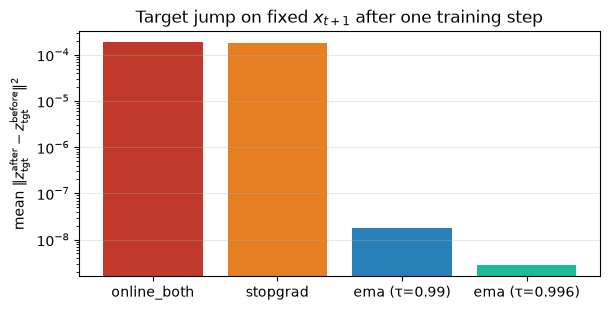

online_both      target jump = 1.848e-04
stopgrad         target jump = 1.777e-04
ema (τ=0.99)     target jump = 1.776e-08
ema (τ=0.996)    target jump = 2.842e-09


In [7]:
def target_jump_after_one_step(mode: str, ema_decay: float = 0.99, seed: int = 0) -> float:
    """How much does the *target* for a fixed x_{t+1} move after one optimizer step?

    This is the moving-target problem in one number:
      large jump  → predictor is chasing a shifting coordinate system
      small jump  → EMA teacher absorbs changes slowly
    """
    torch.manual_seed(seed)
    enc = TinyEncoder()
    pred = nn.Linear(2, 2)
    with torch.no_grad():
        pred.weight.copy_(torch.eye(2))
        pred.bias.zero_()
    target_enc = None
    if mode == "ema":
        target_enc = copy.deepcopy(enc)
        target_enc.requires_grad_(False)

    # Fixed probe set — same futures before and after the update.
    probe = torch.tensor(x_tp1[:512])
    with torch.no_grad():
        if mode == "ema":
            before = target_enc(probe).clone()
        else:
            before = enc(probe).clone()

    xb = torch.tensor(x_t[:128])
    yb = torch.tensor(x_tp1[:128])
    opt = torch.optim.Adam(list(enc.parameters()) + list(pred.parameters()), lr=3e-3)

    z_hat = pred(enc(xb))
    if mode == "online_both":
        z_tgt = enc(yb)
    elif mode == "stopgrad":
        z_tgt = enc(yb).detach()
    else:
        with torch.no_grad():
            z_tgt = target_enc(yb)
    loss = F.mse_loss(z_hat, z_tgt)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if mode == "ema":
        with torch.no_grad():
            for p_s, p_t in zip(enc.parameters(), target_enc.parameters(), strict=True):
                p_t.data.mul_(ema_decay).add_(p_s.data, alpha=1.0 - ema_decay)

    with torch.no_grad():
        if mode == "ema":
            after = target_enc(probe)
        else:
            after = enc(probe)
        return float((after - before).pow(2).mean().item())


jumps = {
    "online_both": target_jump_after_one_step("online_both"),
    "stopgrad": target_jump_after_one_step("stopgrad"),
    "ema (τ=0.99)": target_jump_after_one_step("ema", ema_decay=0.99),
    "ema (τ=0.996)": target_jump_after_one_step("ema", ema_decay=0.996),
}

fig, ax = plt.subplots(figsize=(6.2, 3.2))
names_j = list(jumps.keys())
vals = [jumps[k] for k in names_j]
ax.bar(names_j, vals, color=["#c0392b", "#e67e22", "#2980b9", "#1abc9c"])
ax.set_ylabel(r"mean $\|z_{\mathrm{tgt}}^{\mathrm{after}} - z_{\mathrm{tgt}}^{\mathrm{before}}\|^2$")
ax.set_title("Target jump on fixed $x_{t+1}$ after one training step")
ax.set_yscale("log")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

for k, v in jumps.items():
    print(f"{k:<16} target jump = {v:.3e}")

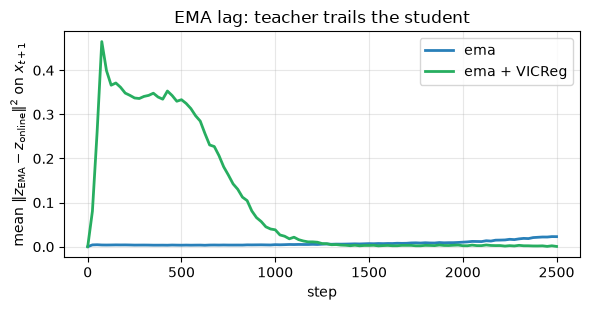

Final scorecard
mode             latent std   phase R²
online_both           0.000      0.000
stopgrad              2.598      0.997
ema                   0.324      0.920
ema + VICReg          2.741      0.997


In [8]:
# EMA teacher trails the online encoder across training (lag, not identity).
fig, ax = plt.subplots(figsize=(6, 3.2))
for name in ("ema", "ema + VICReg"):
    y = results[name]["log"].target_drift
    x = np.linspace(0, 2500, len(y))
    ax.plot(x, y, label=name, color=colors[name], lw=2)
ax.set_xlabel("step")
ax.set_ylabel(r"mean $\|z_{\mathrm{EMA}} - z_{\mathrm{online}}\|^2$ on $x_{t+1}$")
ax.set_title("EMA lag: teacher trails the student")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("Final scorecard")
print(f"{'mode':<14} {'latent std':>12} {'phase R²':>10}")
for name, pack in results.items():
    print(
        f"{name:<14} {pack['log'].latent_std[-1]:12.3f} {pack['log'].phase_r2[-1]:10.3f}"
    )

## 7. What if you don't regularize? (VICReg ablation)

EMA / stop-grad stop the double-gradient cheat, but **prediction loss alone still
allows partial collapse**: the encoder can concentrate information into a few
effective dimensions. Phase readout can still look great — which is exactly why
the real model logs **participation ratio**, not just prediction MSE.

This cell uses a **wider latent** ($d=16$) than the true 1-D phase needs, keeps
the EMA teacher, and compares:

| mode | loss |
|---|---|
| `EMA only` | prediction MSE |
| `EMA + VICReg` | prediction + variance hinge + covariance (as in `jepa_control`) |

Watch participation ratio and per-dimension std — not just phase R².

In [9]:
def participation_ratio(z: np.ndarray) -> float:
    """Effective number of latent dimensions used: (sum λ)² / sum(λ²)."""
    zc = z - z.mean(0, keepdims=True)
    cov = (zc.T @ zc) / max(1, z.shape[0] - 1)
    total = float(np.trace(cov))
    if total <= 0:
        return 0.0
    return float(total**2 / max((cov * cov).sum(), 1e-12))


def vicreg_cov(z: torch.Tensor) -> torch.Tensor:
    zc = z - z.mean(dim=0, keepdim=True)
    cov = (zc.T @ zc) / max(1, z.shape[0] - 1)
    off = cov - torch.diag(torch.diag(cov))
    return (off**2).sum() / z.shape[1]


def train_vicreg_ablation(
    *,
    w_vic_var: float,
    w_vic_cov: float,
    latent_dim: int = 16,
    steps: int = 4000,
    batch_size: int = 256,
    lr: float = 1e-2,
    ema_decay: float = 0.99,
    seed: int = 0,
) -> dict:
    """EMA JEPA on the circle data, with optional VICReg — wider latent."""
    g = torch.Generator().manual_seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)

    enc = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, latent_dim),
    ).to(device)
    pred = nn.Linear(latent_dim, latent_dim, bias=True).to(device)
    with torch.no_grad():
        pred.weight.copy_(torch.eye(latent_dim))
        pred.bias.zero_()

    target_enc = copy.deepcopy(enc)
    target_enc.requires_grad_(False)
    target_enc.eval()

    opt = torch.optim.Adam(list(enc.parameters()) + list(pred.parameters()), lr=lr)
    xt = torch.tensor(x_t, device=device)
    xtp1 = torch.tensor(x_tp1, device=device)
    n = xt.shape[0]

    hist = {k: [] for k in ("step", "pred", "latent_std", "phase_r2", "pr")}
    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), generator=g, device=device)
        z_ctx = enc(xt[idx])
        z_hat = pred(z_ctx)
        with torch.no_grad():
            z_tgt = target_enc(xtp1[idx])
        z_fut = enc(xtp1[idx])
        z_all = torch.cat([z_ctx, z_fut], dim=0)

        loss_pred = F.mse_loss(z_hat, z_tgt)
        loss = loss_pred
        if w_vic_var > 0:
            loss = loss + w_vic_var * vicreg_var(z_all)
        if w_vic_cov > 0:
            loss = loss + w_vic_cov * vicreg_cov(z_all)

        opt.zero_grad()
        loss.backward()
        opt.step()
        with torch.no_grad():
            for p_s, p_t in zip(enc.parameters(), target_enc.parameters(), strict=True):
                p_t.data.mul_(ema_decay).add_(p_s.data, alpha=1.0 - ema_decay)

        if step % 100 == 0 or step == steps:
            with torch.no_grad():
                z = enc(xt).cpu().numpy()
            hist["step"].append(step)
            hist["pred"].append(loss_pred.item())
            hist["latent_std"].append(float(z.std(axis=0).mean()))
            hist["phase_r2"].append(phase_r2(z, phi_t))
            hist["pr"].append(participation_ratio(z))

    with torch.no_grad():
        z_final = enc(xt).cpu().numpy()
    hist["z_final"] = z_final
    hist["latent_dim"] = latent_dim
    return hist


print("training EMA only (no VICReg) ...", flush=True)
abl_off = train_vicreg_ablation(w_vic_var=0.0, w_vic_cov=0.0)
print(
    f"  PR={abl_off['pr'][-1]:.2f}/{abl_off['latent_dim']}  "
    f"std={abl_off['latent_std'][-1]:.3f}  phase R²={abl_off['phase_r2'][-1]:.3f}"
)

print("training EMA + VICReg ...", flush=True)
abl_on = train_vicreg_ablation(w_vic_var=1.0, w_vic_cov=0.1)
print(
    f"  PR={abl_on['pr'][-1]:.2f}/{abl_on['latent_dim']}  "
    f"std={abl_on['latent_std'][-1]:.3f}  phase R²={abl_on['phase_r2'][-1]:.3f}"
)

training EMA only (no VICReg) ...
  PR=5.78/16  std=0.380  phase R²=0.997
training EMA + VICReg ...
  PR=11.94/16  std=1.016  phase R²=0.997


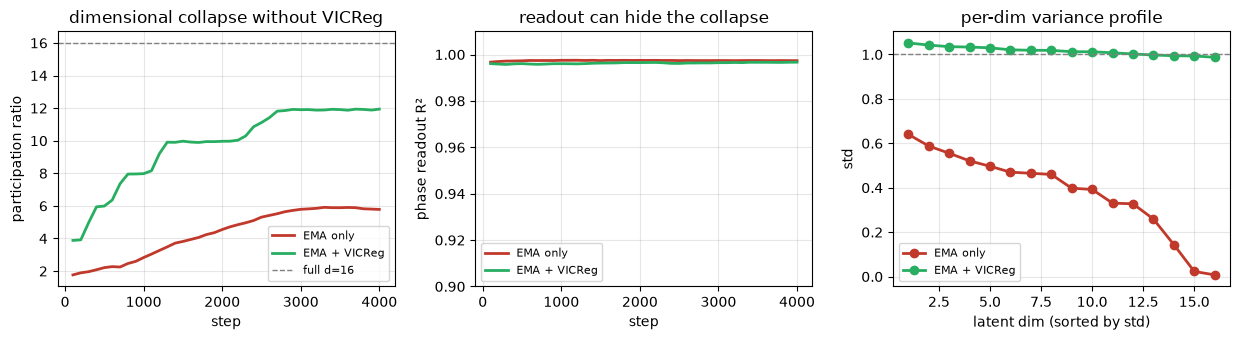

Without VICReg the predictor still works and phase R² stays high,
but only ~5.8 of 16 dimensions are effectively used (vs ~11.9 with VICReg).


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))

# 1) Participation ratio over training
ax = axes[0]
ax.plot(abl_off["step"], abl_off["pr"], color="#c0392b", lw=2, label="EMA only")
ax.plot(abl_on["step"], abl_on["pr"], color="#27ae60", lw=2, label="EMA + VICReg")
ax.axhline(abl_off["latent_dim"], color="gray", ls="--", lw=1, label=f"full d={abl_off['latent_dim']}")
ax.set_xlabel("step")
ax.set_ylabel("participation ratio")
ax.set_title("dimensional collapse without VICReg")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2) Phase R² still looks fine either way
ax = axes[1]
ax.plot(abl_off["step"], abl_off["phase_r2"], color="#c0392b", lw=2, label="EMA only")
ax.plot(abl_on["step"], abl_on["phase_r2"], color="#27ae60", lw=2, label="EMA + VICReg")
ax.set_ylim(0.9, 1.01)
ax.set_xlabel("step")
ax.set_ylabel("phase readout R²")
ax.set_title("readout can hide the collapse")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Per-dimension std at the end
ax = axes[2]
std_off = np.sort(abl_off["z_final"].std(axis=0))[::-1]
std_on = np.sort(abl_on["z_final"].std(axis=0))[::-1]
x = np.arange(1, len(std_off) + 1)
ax.plot(x, std_off, "o-", color="#c0392b", lw=2, label="EMA only")
ax.plot(x, std_on, "o-", color="#27ae60", lw=2, label="EMA + VICReg")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("latent dim (sorted by std)")
ax.set_ylabel("std")
ax.set_title("per-dim variance profile")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(
    "Without VICReg the predictor still works and phase R² stays high,\n"
    "but only ~{:.1f} of {:d} dimensions are effectively used "
    "(vs ~{:.1f} with VICReg).".format(
        abl_off["pr"][-1], abl_off["latent_dim"], abl_on["pr"][-1]
    )
)

## 8. One-slide summary

```
x_t  ──► online f_θ ──► z_t ──► predictor ──► ẑ_{t+1}
                                              │
x_{t+1} ──► target f_θ̄ ──► z̄_{t+1}  (no grad) ◄── MSE
                 ▲
                 └── EMA: θ̄ ← τ θ̄ + (1-τ) θ
```

1. **Don't backprop through the future encoding** (`online_both` → collapse with perfect loss).
2. **Stop-grad** fixes that cheat by freezing the target for the backward pass.
3. **EMA** makes the target a slow teacher (stable latent coordinates for the predictor).
4. **VICReg** keeps the latent high-dimensional — without it, phase readout can still look fine while participation ratio collapses.

That is the same division of labor as in `src/jepa_control/model.py`
(`target="ema"`, `ema_decay=0.996`, VICReg variance + covariance).
